In [2]:
import numpy as np 
import pandas as pd
#loading dataset
df=pd.read_csv('dataset/dataset.csv')
print(df.head(10))

   Unnamed: 0                track_id                               artists  \
0           0  5SuOikwiRyPMVoIQDJUgSV                           Gen Hoshino   
1           1  4qPNDBW1i3p13qLCt0Ki3A                          Ben Woodward   
2           2  1iJBSr7s7jYXzM8EGcbK5b                Ingrid Michaelson;ZAYN   
3           3  6lfxq3CG4xtTiEg7opyCyx                          Kina Grannis   
4           4  5vjLSffimiIP26QG5WcN2K                      Chord Overstreet   
5           5  01MVOl9KtVTNfFiBU9I7dc                          Tyrone Wells   
6           6  6Vc5wAMmXdKIAM7WUoEb7N  A Great Big World;Christina Aguilera   
7           7  1EzrEOXmMH3G43AXT1y7pA                            Jason Mraz   
8           8  0IktbUcnAGrvD03AWnz3Q8             Jason Mraz;Colbie Caillat   
9           9  7k9GuJYLp2AzqokyEdwEw2                        Ross Copperman   

                                          album_name  \
0                                             Comedy   
1                 

In [3]:
#cleaning data
#removing null values
df.dropna(inplace=True)
df.isnull().sum()

Unnamed: 0          0
track_id            0
artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [4]:
df.dtypes

Unnamed: 0            int64
track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object

In [5]:
#creating a dictionary of lower cased track names for fast song search
name_in_indices={}
for i,name in enumerate(df['track_name']):
    key=name.lower()
    if key in name_in_indices:
        name_in_indices[key].append(i)
    else:
        name_in_indices[key]=[i]
#testing dictionary lookup
print(name_in_indices["shape of you"])

[45459, 81030]


In [6]:
print(df.columns)
df.describe()

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')


,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,113999.000000,113999.000000,1.139990e+05,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000
mean,56999.421925,33.238827,2.280312e+05,0.566801,0.641383,5.309126,-8.258950,0.637558,0.084652,0.314907,0.156051,0.213554,0.474066,122.147695,3.904034
std,32909.243463,22.304959,1.072961e+05,0.173543,0.251530,3.559999,5.029357,0.480708,0.105733,0.332522,0.309556,0.190378,0.259261,29.978290,0.432623
min,0.000000,0.000000,8.586000e+03,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.500000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218500,4.000000
50%,56999.000000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.500000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.597500,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [7]:
#data preprocessing
from sklearn.preprocessing import StandardScaler
features=['danceability', 'energy','loudness',
          'speechiness','acousticness','instrumentalness', 
          'liveness', 'valence', 'tempo']
X=df[features].copy()
scaler=StandardScaler()
X[features]=scaler.fit_transform(X[features])
X.describe()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
count,1.139990e+05,1.139990e+05,1.139990e+05,1.139990e+05,1.139990e+05,1.139990e+05,1.139990e+05,1.139990e+05,1.139990e+05
mean,-9.972617e-17,1.954633e-16,-1.555728e-16,1.595619e-17,-7.978094e-18,-2.393428e-17,5.385213e-17,-1.595619e-17,4.567459e-16
std,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00
min,-3.266071e+00,-2.549938e+00,-8.206263e+00,-8.006285e-01,-9.470287e-01,-5.041145e-01,-1.121741e+00,-1.828535e+00,-4.074556e+00
25%,-6.384656e-01,-6.734145e-01,-3.487638e-01,-4.610919e-01,-8.962048e-01,-5.041145e-01,-6.069741e-01,-8.256808e-01,-7.648634e-01
50%,7.605855e-02,1.734064e-01,2.495260e-01,-3.381399e-01,-4.387898e-01,-5.039801e-01,-4.283813e-01,-3.882571e-02,-4.359668e-03
75%,7.387221e-01,8.452970e-01,6.473917e-01,-1.440658e-03,8.498512e-01,-3.458225e-01,3.122534e-01,8.058864e-01,5.978788e-01
max,2.409787e+00,1.425747e+00,2.543268e+00,8.326191e+00,2.048272e+00,2.726334e+00,4.130987e+00,2.009312e+00,4.043754e+00


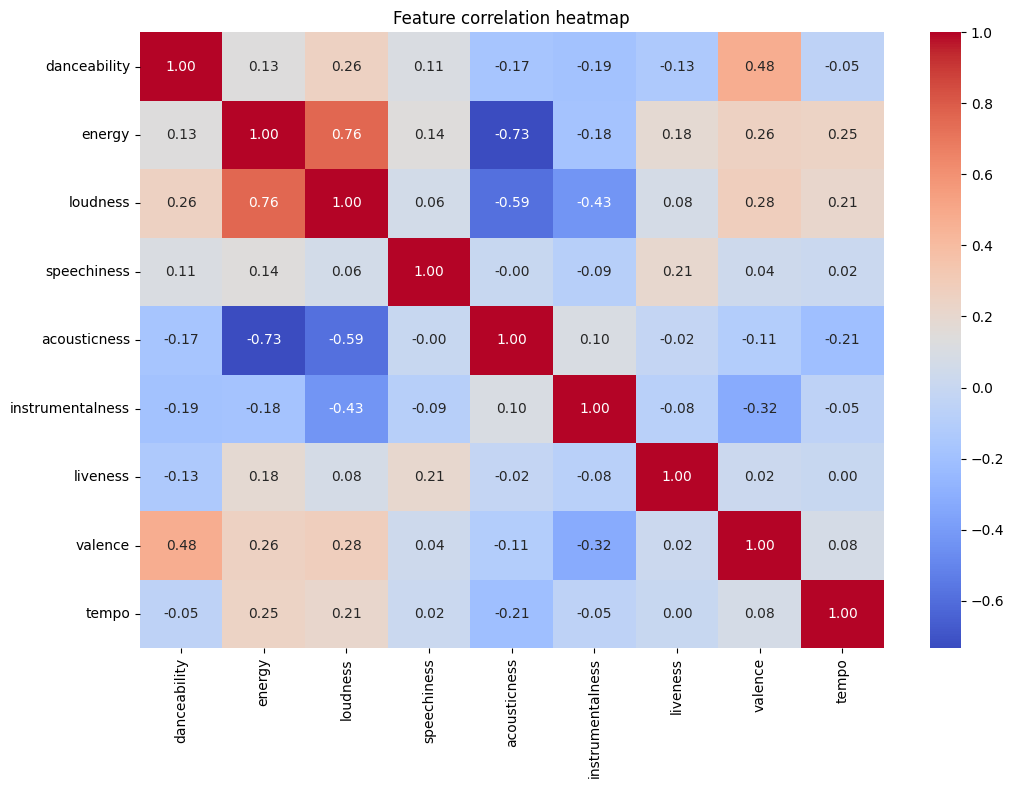

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
corr=df[features].corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt='.2f')
plt.title('Feature correlation heatmap')
plt.show()

In [9]:
#converting X to numpy for better computation
X=X.to_numpy()
#adding weights to features
weights={
         'danceability':1, 
         'energy':1,
         'loudness':0.5,
         'speechiness':0.5,
         'acousticness':1,
         'instrumentalness':0.7, 
          'liveness':0.5, 
          'valence':0.9, 
          'tempo':0.7
}
weight_array=np.array([weights[col] for col in features])
X=X*weight_array

In [10]:
#manual normalization
norm=np.linalg.norm(X,axis=1,keepdims=True)
norm[norm==0]=1
X=X/norm
#checking for normalization correctness
norms=np.linalg.norm(X,axis=1)
print(norms[:10]) 
#prints all 1 if normalization successful

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [11]:
#recommendation algorithm
def recommend(song_index,top_n=10):
    song_vector=X[song_index]
    similarities=np.dot(X,song_vector)#cosine similarity
    similarities[song_index]=-1
    top_indices=np.argpartition(similarities,-top_n)[-top_n:]
    top_indices=top_indices[np.argsort(similarities[top_indices])[::-1]]
    return df.at[top_indices,'track_name','artists']

In [ ]:
def search_song(song_name):
    key = song_name.lower()
    if key not in name_in_indices:
        print("Song not found.")
        return None
    indices = name_in_indices[key]
    for i, idx in enumerate(indices):
        print(f"{i}->{df.iloc[idx]['track_name']} | {df.iloc[idx]['artists']}")
    return indices

In [17]:
def rec():
    song_name=input("Enter exact song name: ")
    indices=search_song(song_name)
    if indices is None:
        return
    choice=int(input("Choose song number: "))
    song_index=indices[choice]
    return recommend(song_index)

In [15]:
rec()

0->Shape Of You | Andrew Foy
1->Let Me Down Slowly | Alec Benjamin


TypeError: DataFrame._get_value() got multiple values for argument 'takeable'